In [1]:
!pip install lunardate

In [2]:
import numpy as np
import pandas as pd
from lunardate import LunarDate
import os, gc, warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/hbaac-round2/sample_submission.csv
/kaggle/input/competitions/hbaac-round2/train.csv


In [3]:
# =====================================================================
# 1. LOAD & EXPLORE DATA
# =====================================================================
sample    = pd.read_csv("/kaggle/input/competitions/hbaac-round2/sample_submission.csv")
train_raw = pd.read_csv("/kaggle/input/competitions/hbaac-round2/train.csv")

print("── sample ──"); display(sample.head())
print("\n── train ──"); display(train_raw.head())


── sample ──


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,SKU-00002_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,SKU-00003_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,SKU-00004_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,SKU-00005_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



── train ──


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000


,Kiểu dữ liệu,Giá trị duy nhất,Số lượng trống,Tỷ lệ (%)
Date,object,1411,0,0.0
Stt,object,327283,0,0.0
ItemCode,object,15972,0,0.0
Quantity,int64,360,0,0.0
UnitPrice,object,24114,0,0.0
SalesAmount,int64,52820,0,0.0
Unit Cost,object,149008,0,0.0
Cost Amount,object,182660,0,0.0


,Quantity
count,711980.000000
mean,3.437250
std,25.490722
min,-998.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5998.000000


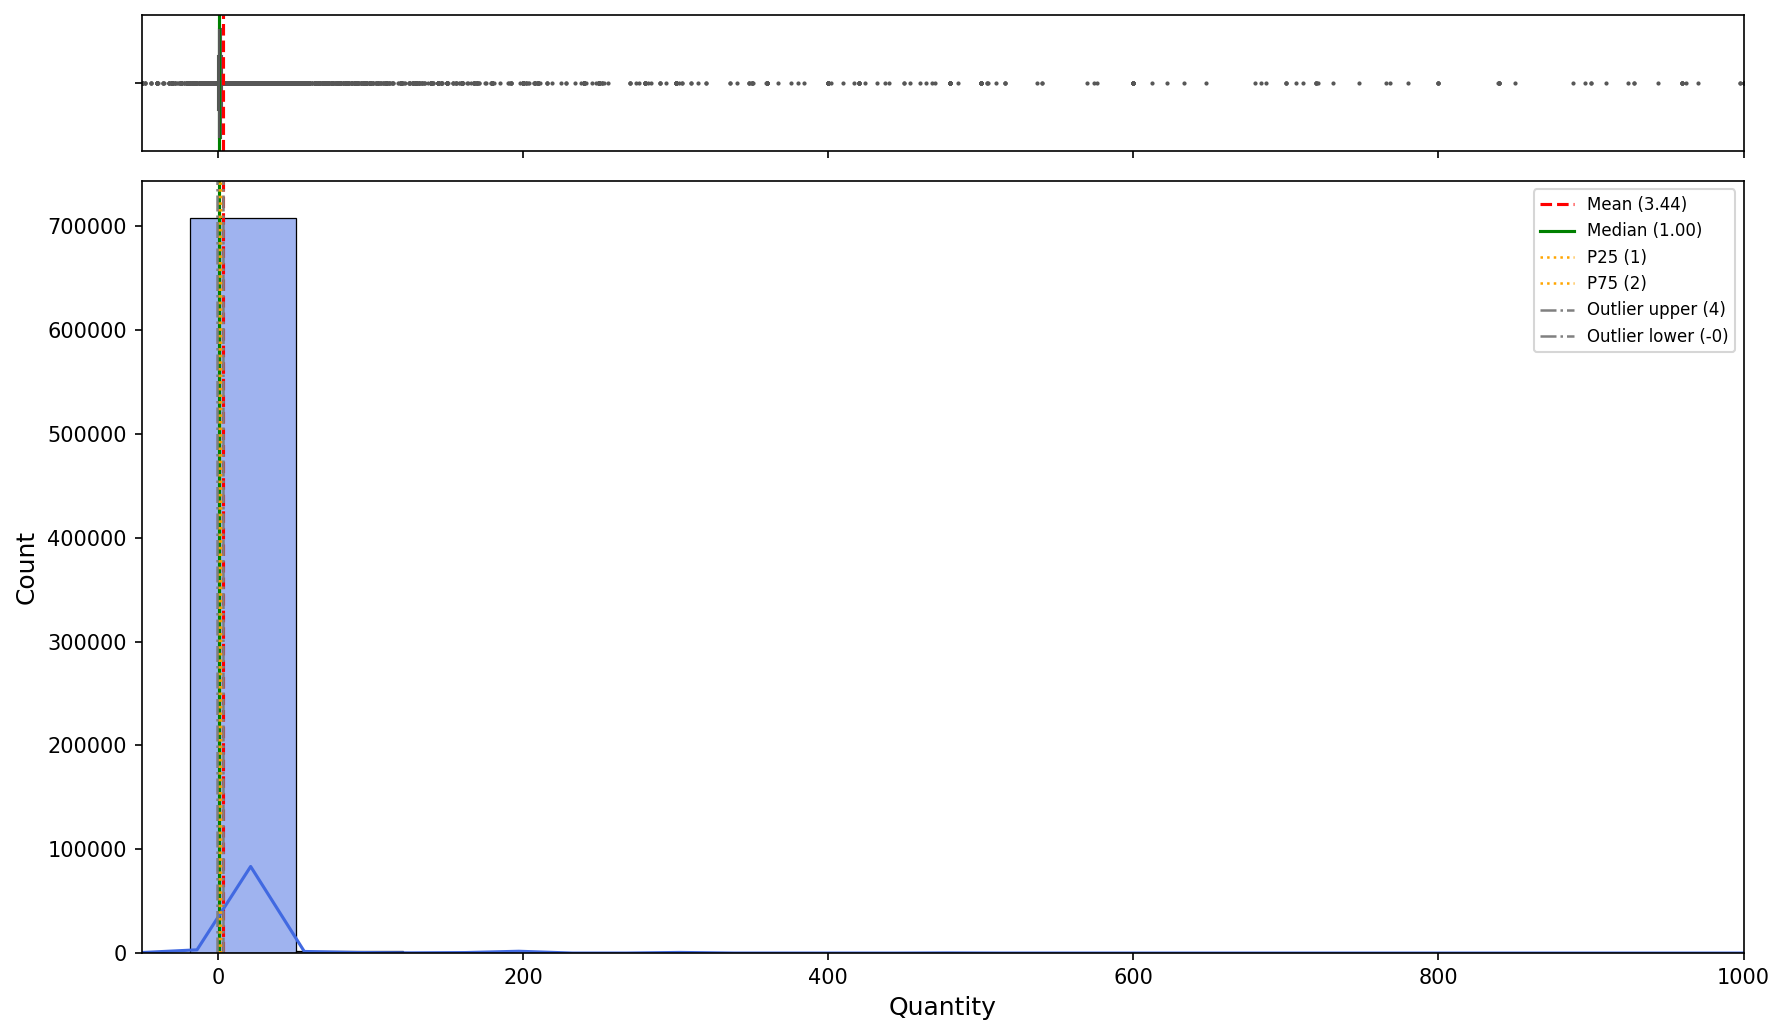

In [4]:
# =====================================================================
# 2. EXPLORATORY DATA ANALYSIS
# =====================================================================

def check_data(df):
    return pd.DataFrame({
        'Kiểu dữ liệu'  : df.dtypes.astype(str),
        'Giá trị duy nhất': df.nunique(),
        'Số lượng trống' : df.isnull().sum(),
        'Tỷ lệ (%)'      : (df.isnull().mean() * 100).round(2),
    })

display(check_data(train_raw))
display(train_raw[["Quantity"]].describe())

# ── Distribution plot ──
qty = train_raw['Quantity']
mean_qty, median_qty = qty.mean(), qty.median()
q25, q75 = qty.quantile(0.25), qty.quantile(0.75)
iqr = q75 - q25
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr

f, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)}, dpi=150
)

sns.boxplot(x=qty, color='royalblue', fliersize=1, ax=ax_box)
for ax in (ax_box, ax_hist):
    ax.axvline(mean_qty,   color='red',    ls='--', lw=1.5, label=f'Mean ({mean_qty:.2f})')
    ax.axvline(median_qty, color='green',  ls='-',  lw=1.5, label=f'Median ({median_qty:.2f})')

sns.histplot(qty, kde=True, color='royalblue', ax=ax_hist, bins=100)
for val, label, c, ls in [
    (q25,         f'P25 ({q25:.0f})',          'orange', ':'),
    (q75,         f'P75 ({q75:.0f})',          'orange', ':'),
    (upper_bound, f'Outlier upper ({upper_bound:.0f})', 'gray',   '-.'),
    (lower_bound, f'Outlier lower ({lower_bound:.0f})', 'gray',   '-.'),
]:
    ax_hist.axvline(val, color=c, ls=ls, lw=1.2, label=label)

ax_hist.set_xlim(-50, 1000)
ax_hist.set_xlabel('Quantity', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [5]:
# =====================================================================
# 3. PREPROCESSING & FEATURE ENGINEERING
# =====================================================================

pd.options.display.float_format = lambda x: f"{x:,.0f}" if x == int(x) else f"{x:,.2f}"

train = train_raw.copy()
train["Date"] = pd.to_datetime(train["Date"])

# Fix decimal separator in price columns
for col in ["UnitPrice", "Unit Cost"]:
    if col in train.columns and train[col].dtype == object:
        train[col] = train[col].str.replace(",", ".").astype(float)

# ── 3.1 Aggregate by Date × ItemCode ─────────────────────────────────
# Use median for prices (more robust than first/mean)
train_1 = (
    train
    .drop(columns=["Stt", "SalesAmount", "Cost Amount"], errors="ignore")
    .groupby(["Date", "ItemCode"], as_index=False)
    .agg({"Quantity": "sum", "UnitPrice": "median", "Unit Cost": "median"})
)

# ── 3.2 Clip negative quantities & cap at 99.9th percentile ──────────
train_2 = train_1.copy()
train_2["Quantity"] = train_2["Quantity"].clip(lower=0)
cap = train_2["Quantity"].quantile(0.999)
train_2["Quantity"] = train_2["Quantity"].clip(upper=cap)

# ── 3.3 Reindex to continuous daily grid ─────────────────────────────
all_dates = pd.date_range(train_2["Date"].min(), train_2["Date"].max())
all_skus  = train_2["ItemCode"].unique()

train_3 = (
    train_2
    .set_index(["Date", "ItemCode"])
    .reindex(pd.MultiIndex.from_product([all_dates, all_skus], names=["Date", "ItemCode"]))
    .reset_index()
)
train_3["Quantity"] = train_3["Quantity"].fillna(0)
for col in ["UnitPrice", "Unit Cost"]:
    train_3[col] = train_3.groupby("ItemCode")[col].ffill().bfill()

# ── 3.4 Calendar features ─────────────────────────────────────────────
train_4 = train_3.copy()

# 1. Đặc trưng thời gian (Bổ sung WeekOfYear và Quarter)
train_4["Month"] = train_4["Date"].dt.month
train_4["DayofMonth"] = train_4["Date"].dt.day
train_4["DayofWeek"] = train_4["Date"].dt.dayofweek
train_4["WeekOfYear"] = train_4["Date"].dt.isocalendar().week.astype(int) # Mới
train_4["Quarter"] = train_4["Date"].dt.quarter # Mới
train_4["Is_Weekend"] = (train_4["DayofWeek"] >= 5).astype(int)

# 2. Season (Giữ nguyên)
train_4["Season"] = np.select(
    [train_4["Month"].isin([2,3,4]), train_4["Month"].isin([5,6,7]), train_4["Month"].isin([8,9,10])],
    [1,2,3], default=4
)

# 3. Lags (Đảm bảo có đủ 28, 35, 56)
train_4 = train_4.sort_values(["ItemCode","Date"]).reset_index(drop=True)
g = train_4.groupby("ItemCode")["Quantity"]
train_4["lag_28"] = g.shift(28)
train_4["lag_35"] = g.shift(35)
train_4["lag_56"] = g.shift(56)

# 4. Rolling (Bổ sung mean_14, std_28, max_28)
g_lag = train_4.groupby("ItemCode")["lag_28"]
train_4["rolling_mean_7"] = g_lag.transform(lambda x: x.rolling(7).mean())
train_4["rolling_mean_14"] = g_lag.transform(lambda x: x.rolling(14).mean()) # Mới
train_4["rolling_mean_28"] = g_lag.transform(lambda x: x.rolling(28).mean())
train_4["rolling_std_7"] = g_lag.transform(lambda x: x.rolling(7).std())
train_4["rolling_std_28"] = g_lag.transform(lambda x: x.rolling(28).std()) # Mới
train_4["rolling_max_28"] = g_lag.transform(lambda x: x.rolling(28).max()) # Mới

# 5. Đừng quên xóa Na sau khi tạo Lag/Rolling
train_4.dropna(subset=["lag_56", "rolling_mean_28"], inplace=True)
# ── 3.5 Lunar & holiday features (vectorised, computed once) ──────────
unique_dates = pd.DataFrame({"Date": train_4["Date"].unique()})

def get_lunar_month_day(d):
    lun = LunarDate.fromSolarDate(d.year, d.month, d.day)
    return pd.Series([lun.month, lun.day])

unique_dates[["L_Month", "L_Day"]] = unique_dates["Date"].apply(get_lunar_month_day)

solar_fest = {(1,1),(2,14),(2,27),(3,8),(4,1),(4,30),(5,1),(5,13),(5,19),
              (6,1),(6,17),(9,2),(10,20),(10,31),(11,19),(11,20),(12,24)}
lunar_fest = {(1,1),(1,2),(1,3),(1,4),(1,5),(1,15),(3,3),(3,10),
              (4,15),(5,5),(7,7),(7,15),(8,15),(12,23)}

# ★ IMPROVED: pre-holiday & post-holiday signals (±1 day effect)
def classify_holiday(row):
    solar_key = (row["Date"].month, row["Date"].day)
    lunar_key  = (row["L_Month"], row["L_Day"])
    # Check ±1 day for solar
    prev_d = row["Date"] - pd.Timedelta(days=1)
    next_d = row["Date"] + pd.Timedelta(days=1)
    prev_solar = (prev_d.month, prev_d.day)
    next_solar = (next_d.month, next_d.day)
    if solar_key in solar_fest or lunar_key in lunar_fest:
        return 2  # holiday itself
    if prev_solar in solar_fest or next_solar in solar_fest:
        return 1  # adjacent to solar holiday
    return 0

unique_dates["Is_Holiday"] = unique_dates.apply(classify_holiday, axis=1)
train_4 = train_4.merge(unique_dates[["Date", "Is_Holiday"]], on="Date", how="left")

# ── 3.6 Lag & rolling features (leak-safe: min lag = 28) ─────────────
train_4 = train_4.sort_values(["ItemCode", "Date"]).reset_index(drop=True)
g = train_4.groupby("ItemCode")["Quantity"]

for lag in [28, 35, 56]:
    train_4[f"lag_{lag}"] = g.shift(lag)

# Rolling windows computed on lag_28 series (no future leakage)
g_lag = train_4.groupby("ItemCode")["lag_28"]
for window in [7, 14, 28]:
    train_4[f"rolling_mean_{window}"] = g_lag.transform(lambda x: x.rolling(window).mean())  # ★ added 14
train_4["rolling_std_7"]  = g_lag.transform(lambda x: x.rolling(7).std())
train_4["rolling_std_28"] = g_lag.transform(lambda x: x.rolling(28).std())  # ★ NEW
train_4["rolling_max_28"] = g_lag.transform(lambda x: x.rolling(28).max())  # ★ NEW — captures peak demand

# Drop rows without full lag history
train_4.dropna(subset=["lag_56", "rolling_mean_28"], inplace=True)
train_4.reset_index(drop=True, inplace=True)

display(train_4.head())
print("Shape:", train_4.shape)


,Date,ItemCode,Quantity,UnitPrice,Unit Cost,Month,DayofMonth,DayofWeek,WeekOfYear,Quarter,...,lag_28,lag_35,lag_56,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_28,rolling_max_28,Is_Holiday
0,2021-03-09,SKU-00001,0,"242,727.27","123,559.10",3,9,1,10,1,...,0,0,0,0,0,0,0,0,0,1
1,2021-03-10,SKU-00001,0,"242,727.27","123,559.10",3,10,2,10,1,...,0,0,0,0,0,0,0,0,0,0
2,2021-03-11,SKU-00001,0,"242,727.27","123,559.10",3,11,3,10,1,...,0,0,0,0,0,0,0,0,0,0
3,2021-03-12,SKU-00001,0,"242,727.27","123,559.10",3,12,4,10,1,...,0,0,0,0,0,0,0,0,0,0
4,2021-03-13,SKU-00001,0,"242,727.27","123,559.10",3,13,5,10,1,...,0,0,0,0,0,0,0,0,0,0


Shape: (26226024, 22)


In [6]:
import gc

# 1. Ép kiểu ItemCode về category (giúp giảm RAM cực lớn)
train_4["ItemCode"] = train_4["ItemCode"].astype("category")

# 2. Ép kiểu Float64 về Float32 (Giảm 50% dung lượng cột số thực mà không mất độ chính xác)
# Thay vì dùng loop và downcast, ta chỉ định trực tiếp
float_cols = train_4.select_dtypes(include=['float64']).columns
train_4[float_cols] = train_4[float_cols].astype('float32')

# 3. Ép kiểu Int64 về Int32 (Giảm 50% dung lượng cột số nguyên)
int_cols = train_4.select_dtypes(include=['int64']).columns
train_4[int_cols] = train_4[int_cols].astype('int32')

# 4. Giải phóng bộ nhớ ngay lập tức
gc.collect()

print("RAM sau tối ưu:", round(train_4.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

RAM sau tối ưu: 2252.4 MB


Shapes — Train: (25331592, 20) Val: (447216, 20) Test: (447216, 20)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.793280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17610
[LightGBM] [Info] Number of data points in the train set: 25331592, number of used features: 20
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 0.085283

Best iteration: 49

──────────────────────────────
  RMSE : 1.839
  MAE  : 0.136
  MAPE : 87.05%
  R²   : 0.1623
─────────────────

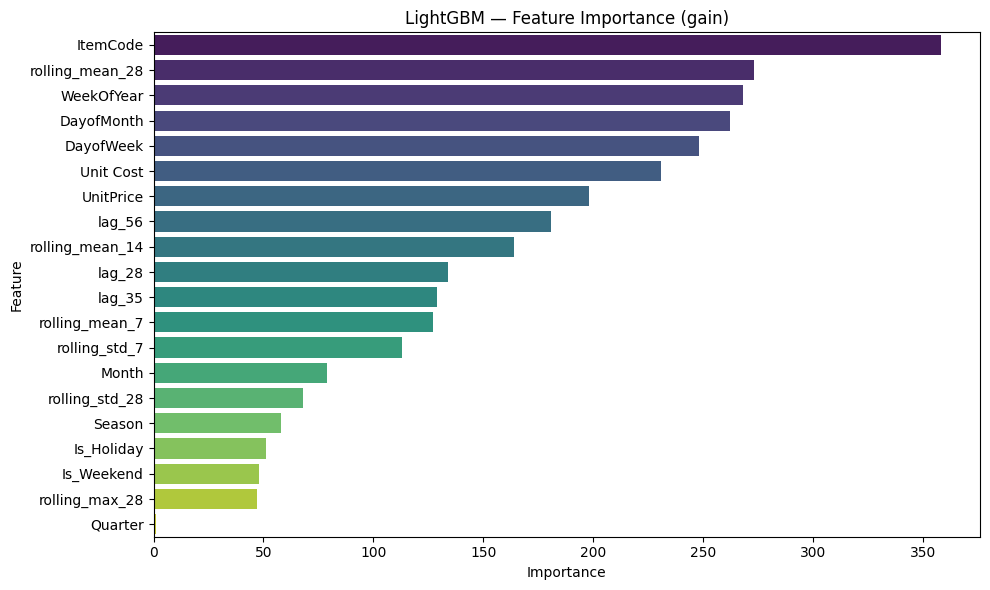

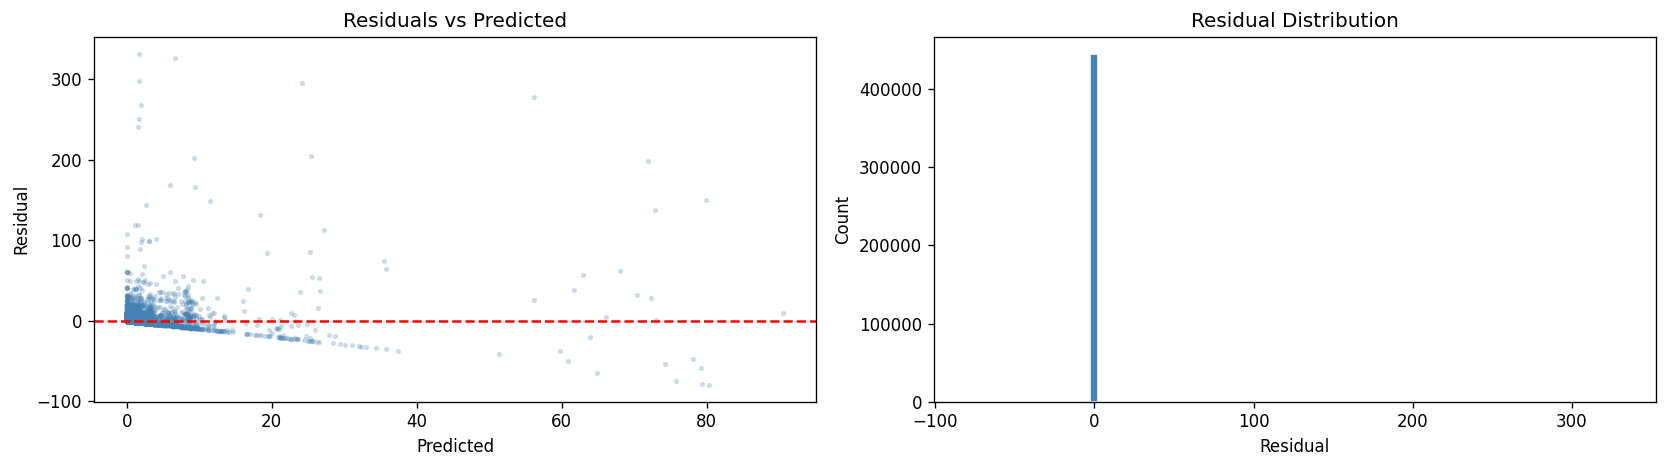

In [7]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 4. FEATURE LIST
# =====================================================================
train_4["ItemCode"] = train_4["ItemCode"].astype("category")

features = [
    "ItemCode", "UnitPrice", "Unit Cost",
    "Month", "DayofMonth", "DayofWeek",
    "Is_Weekend", "WeekOfYear", "Quarter",   # ★ added WeekOfYear, Quarter
    "Season", "Is_Holiday",
    "lag_28", "lag_35", "lag_56",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",  # ★ added rolling_mean_14
    "rolling_std_7", "rolling_std_28",     # ★ added rolling_std_28
    "rolling_max_28",                      # ★ peak demand signal
]

target = "Quantity"

# =====================================================================
# 5. TIME-BASED SPLIT  (28-day test | 28-day val | rest = train)
# =====================================================================
max_date   = train_4["Date"].max()
test_start = max_date - pd.Timedelta(days=27)
val_start  = test_start - pd.Timedelta(days=28)

X_train = train_4.loc[train_4["Date"] < val_start,  features]
y_train = train_4.loc[train_4["Date"] < val_start,  target]

X_val   = train_4.loc[(train_4["Date"] >= val_start) & (train_4["Date"] < test_start), features]
y_val   = train_4.loc[(train_4["Date"] >= val_start) & (train_4["Date"] < test_start), target]

X_test  = train_4.loc[train_4["Date"] >= test_start, features]
y_test  = train_4.loc[train_4["Date"] >= test_start, target]

print("Shapes — Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# =====================================================================
# 6. LIGHTGBM — IMPROVED HYPERPARAMETERS
# =====================================================================
# ★ Key changes vs original:
#   • num_leaves 31→63  (more expressive tree structure)
#   • min_child_samples=20  (prevent overfit on sparse SKUs)
#   • reg_alpha/reg_lambda  (L1+L2 regularisation)
#   • n_estimators 1500→2000 with early stopping — safe to raise
#   • log_evaluation callback to see val RMSE every 100 rounds

model = lgb.LGBMRegressor(
    objective         = "regression",
    n_estimators      = 2000,
    learning_rate     = 0.03,
    num_leaves        = 63,           # ★ wider trees
    min_child_samples = 20,           # ★ anti-overfit on rare SKUs
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,          # ★ L1
    reg_lambda        = 0.1,          # ★ L2
    random_state      = 42,
    n_jobs            = -1,
)

model.fit(
    X_train, y_train,
    eval_set   = [(X_val, y_val)],
    eval_metric= "rmse",
    callbacks  = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),      # ★ print val RMSE every 100 rounds
    ],
)

print("\nBest iteration:", model.best_iteration_)

# =====================================================================
# 7. EVALUATION
# =====================================================================
y_pred = np.clip(model.predict(X_test, num_iteration=model.best_iteration_), 0, None)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

# ★ NEW: MAPE (skip zero actuals to avoid div-by-zero)
mask  = y_test > 0
mape  = (np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])).mean() * 100

print(f"\n{'─'*30}")
print(f"  RMSE : {rmse:.3f}")
print(f"  MAE  : {mae:.3f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")
print(f"{'─'*30}")

# =====================================================================
# 8. FEATURE IMPORTANCE
# =====================================================================
importance = (
    pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x="Importance", y="Feature",
            hue="Feature", legend=False, palette="viridis")
plt.title("LightGBM — Feature Importance (gain)")
plt.tight_layout()
plt.show()

# =====================================================================
# 9. RESIDUAL ANALYSIS  ★ NEW
# =====================================================================
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)

axes[0].scatter(y_pred, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=80, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout(); plt.show()
